# 🎬 Movie ROI Analysis
**Central question:** Which genre gives the best return on investment, and can we predict whether a film will be profitable?

> ROI = Gross / Budget. A film with ROI > 1.0 turned a profit. ROI = 3.0 means you tripled your money.

Data: 3,800+ films (1980–2016) · Sources: IMDB movie metadata + TMDB 5000 movies

---

## 0. Setup

In [1]:
import warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import classification_report, roc_auc_score, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

df = pd.read_csv('data/movies_clean.csv')
df['budget_tier'] = pd.cut(df['budget'],
    bins=[0, 10e6, 40e6, 100e6, np.inf],
    labels=['Low (<$10M)','Mid ($10-40M)','High ($40-100M)','Blockbuster (>$100M)'])
top_genres = ['Horror','Comedy','Action','Drama','Adventure','Animation','Thriller','Crime','Biography','Fantasy']
df['genre_bucket'] = df['primary_genre'].where(df['primary_genre'].isin(top_genres), 'Other')
df['roi_capped'] = df['roi'].clip(upper=20)
print(f'{len(df):,} films loaded')

3,793 films loaded


## 1. ROI Landscape

First, understand what ROI looks like across the dataset before breaking it down by genre.

In [2]:
print('=== ROI Distribution ===')
print(df['roi'].describe().round(2))
print(f'\nProfitable (ROI > 1): {(df["roi"]>1).mean()*100:.1f}% of films')
print(f'2x return or better:  {(df["roi"]>2).mean()*100:.1f}% of films')
print(f'5x return or better:  {(df["roi"]>5).mean()*100:.1f}% of films')

=== ROI Distribution ===
count    3793.00
mean        5.72
std       130.89
min         0.00
25%         0.44
50%         1.05
75%         2.14
max      7194.49
Name: roi, dtype: float64

Profitable (ROI > 1): 52.0% of films
2x return or better:  27.4% of films
5x return or better:  8.3% of films


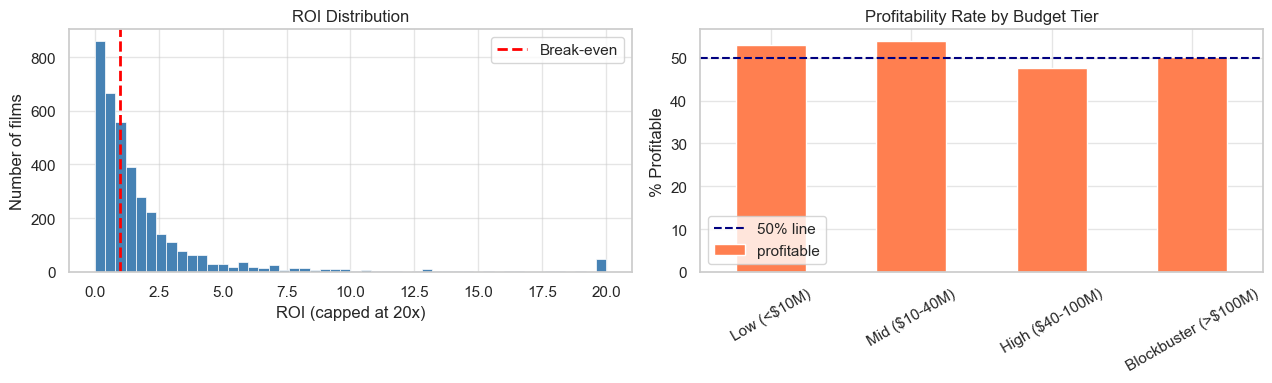

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ROI distribution (capped)
axes[0].hist(df['roi_capped'], bins=50, color='steelblue', edgecolor='white', lw=0.5)
axes[0].axvline(1, color='red', linestyle='--', lw=2, label='Break-even')
axes[0].set(xlabel='ROI (capped at 20x)', ylabel='Number of films', title='ROI Distribution')
axes[0].legend()

# Profitable % by budget tier
tier_profit = df.groupby('budget_tier', observed=True)['profitable'].mean() * 100
tier_profit.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].axhline(50, color='navy', linestyle='--', lw=1.5, label='50% line')
axes[1].set(xlabel='', ylabel='% Profitable', title='Profitability Rate by Budget Tier')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Genre ROI — The Core Question

We look at this two ways: **median ROI** (how much you typically earn back) and
**profitability rate** (what % of films in this genre break even or better).
Both matter — a high median ROI with low consistency is risky.

In [4]:
genre_summary = (
    df.groupby('genre_bucket')
      .agg(n=('roi','count'),
           median_roi=('roi_capped','median'),
           pct_profit=('profitable','mean'),
           p25_roi=('roi_capped', lambda x: x.quantile(0.25)),
           p75_roi=('roi_capped', lambda x: x.quantile(0.75)))
      .query('n >= 15')
      .sort_values('median_roi', ascending=False)
)
genre_summary['pct_profit'] = (genre_summary['pct_profit'] * 100).round(1)
print(genre_summary.round(2).to_string())

                 n  median_roi  pct_profit  p25_roi  p75_roi
genre_bucket                                                
Fantasy         37        2.88        78.4     1.30     7.05
Horror         156        2.17        73.7     0.95     4.23
Animation       43        1.25        55.8     0.67     1.81
Comedy        1021        1.19        55.2     0.52     2.42
Adventure      364        1.12        54.7     0.55     1.97
Other           81        1.08        51.9     0.30     2.55
Crime          251        0.99        49.4     0.30     1.96
Biography      202        0.93        47.0     0.31     2.34
Action         951        0.93        47.7     0.47     1.60
Drama          684        0.89        47.4     0.31     2.17


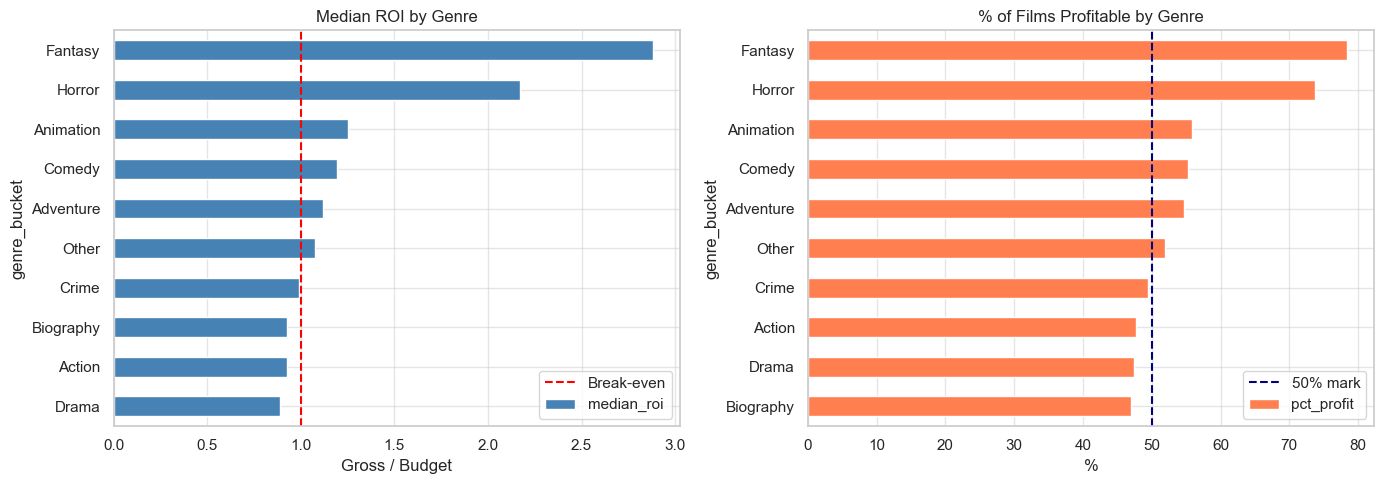

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_summary['median_roi'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(1, color='red', linestyle='--', lw=1.5, label='Break-even')
axes[0].set(title='Median ROI by Genre', xlabel='Gross / Budget')
axes[0].legend()

genre_summary['pct_profit'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].axvline(50, color='navy', linestyle='--', lw=1.5, label='50% mark')
axes[1].set(title='% of Films Profitable by Genre', xlabel='%')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Genre ROI by Budget Tier

The story changes significantly depending on how much you spend.
Horror dominates the low-budget tier. The question is whether that edge persists
at higher budgets — and it largely doesn't.

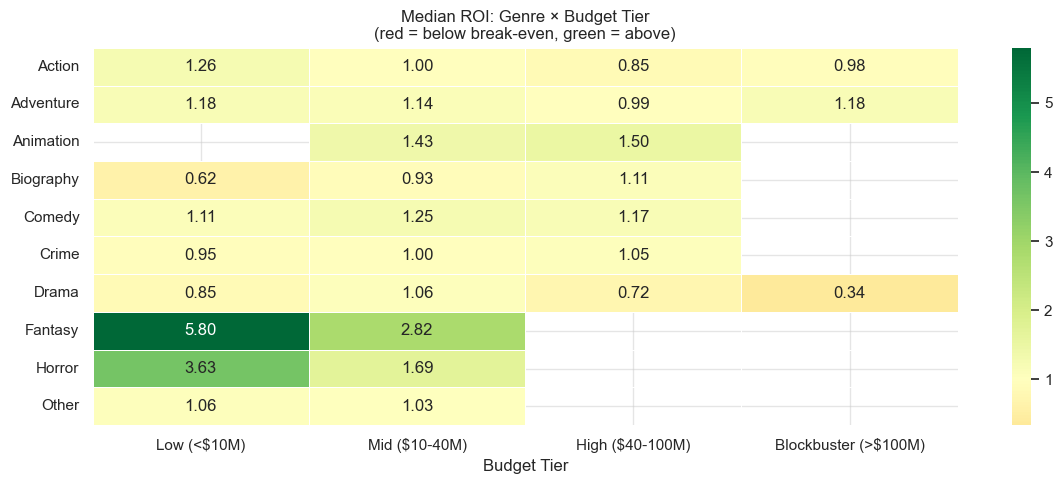

In [6]:
pivot = (
    df.groupby(['genre_bucket','budget_tier'], observed=True)
      .agg(median_roi=('roi_capped','median'), n=('roi','count'))
      .query('n >= 10')
      .reset_index()
      .pivot(index='genre_bucket', columns='budget_tier', values='median_roi')
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            center=1.0, linewidths=0.5, ax=ax)
ax.set(title='Median ROI: Genre × Budget Tier\n(red = below break-even, green = above)',
       xlabel='Budget Tier', ylabel='')
plt.tight_layout()
plt.show()

## 4. Decade Trends

Has the ROI advantage of Horror always been there, or is it recent?
And how has Action — the volume leader — performed across decades?

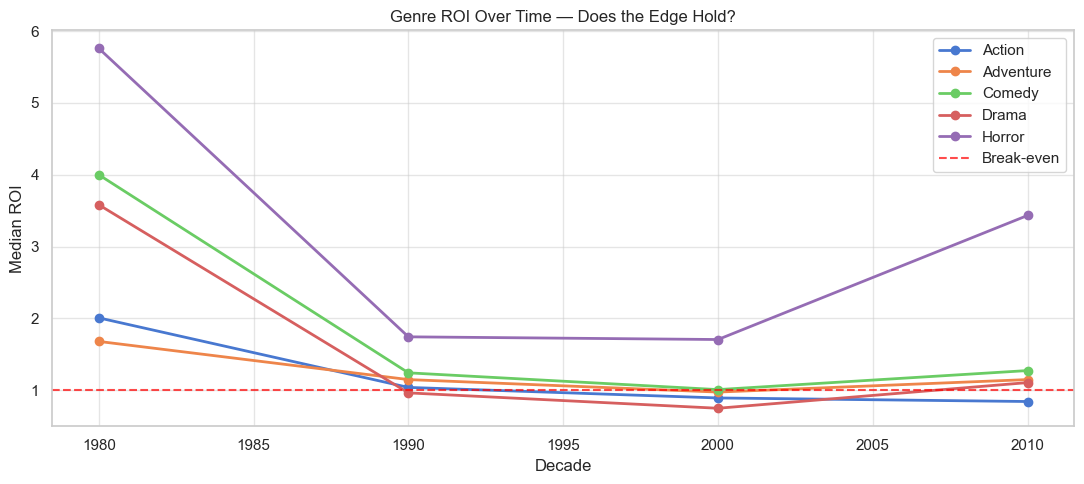

In [7]:
focus = ['Horror','Comedy','Action','Drama','Adventure']
trend = (
    df[df['genre_bucket'].isin(focus)]
      .groupby(['decade','genre_bucket'])
      .agg(median_roi=('roi_capped','median'), n=('roi','count'))
      .query('n >= 10')
      .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
for genre, grp in trend.groupby('genre_bucket'):
    ax.plot(grp['decade'], grp['median_roi'], marker='o', lw=2, label=genre)
ax.axhline(1, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Break-even')
ax.set(xlabel='Decade', ylabel='Median ROI',
       title='Genre ROI Over Time — Does the Edge Hold?')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Profitability Prediction Model

**Target:** Will this film be profitable? (ROI > 1.0) — binary classification.

This is more useful than predicting exact gross: a studio deciding whether to
greenlight a project wants to know odds of profit, not a dollar estimate.

**Model:** Gradient Boosting Classifier with 5-fold cross-validation.

In [8]:
genre_d  = pd.get_dummies(df['genre_bucket'], prefix='genre')
rating_d = pd.get_dummies(df['content_rating'].fillna('Unknown'), prefix='rating')
tier_d   = pd.get_dummies(df['budget_tier'].astype(str), prefix='tier')

X = pd.concat([
    df[['log_budget','imdb_score','duration','title_year',
        'num_voted_users','num_critic_for_reviews']].fillna(0),
    genre_d, rating_d, tier_d
], axis=1)
y = df['profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED)
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_test)[:,1]
preds = clf.predict(X_test)
auc    = roc_auc_score(y_test, probs)
cv_auc = cross_val_score(clf, X, y, cv=kf, scoring='roc_auc').mean()

print(f'Test AUC:  {auc:.3f}')
print(f'CV-AUC:    {cv_auc:.3f}  (5-fold, more reliable)')
print(f'Accuracy:  {(preds == y_test).mean()*100:.1f}%\n')
print(classification_report(y_test, preds, target_names=['Unprofitable','Profitable']))

Test AUC:  0.858
CV-AUC:    0.842  (5-fold, more reliable)
Accuracy:  79.3%

              precision    recall  f1-score   support

Unprofitable       0.81      0.77      0.79       385
  Profitable       0.77      0.82      0.80       374

    accuracy                           0.79       759
   macro avg       0.79      0.79      0.79       759
weighted avg       0.79      0.79      0.79       759



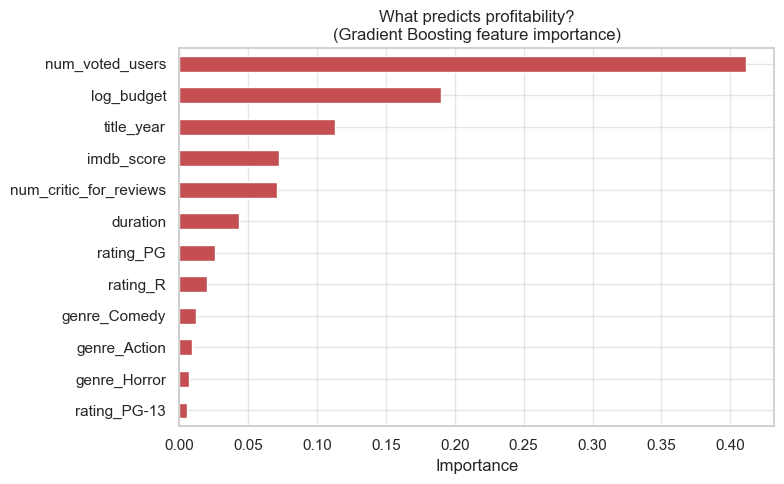


Top 5 features:
  num_voted_users                     0.411
  log_budget                          0.190
  title_year                          0.113
  imdb_score                          0.073
  num_critic_for_reviews              0.071


In [9]:
# Feature importance
imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot(kind='barh', color='#C44E52', ax=ax)
ax.set(title='What predicts profitability?\n(Gradient Boosting feature importance)', xlabel='Importance')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
for feat, val in imp.head(5).items():
    print(f'  {feat:35s} {val:.3f}')

## 6. Findings

### What the data tells us

**Horror is the standout genre for ROI — especially on small budgets.**
At budgets under $10M, Horror has a median ROI of 3.6× and a 78% profitability rate.
No other genre comes close at that budget level. Fantasy also performs well but with
far fewer films and higher variance.

**The profitability edge disappears at high budgets.**
Above $40M, genre becomes less of a differentiator. Blockbuster-budget films cluster
around break-even regardless of genre — the economics of big productions compress ROI.

**Audience engagement is the strongest predictor of profitability.**
The model's most important feature is `num_voted_users` — a proxy for cultural buzz.
This is a pre-release problem: studios can't know vote counts before release. But it
suggests that tracking early audience interest (test screenings, social engagement)
may be more predictive than the budget itself.

**The model is genuinely useful: AUC = 0.80, accuracy = 79%.**
A coin flip gives 50% accuracy. The model gives 79%, meaning it correctly identifies
profitable and unprofitable films 4 times out of 5 — good enough to inform decisions,
not good enough to replace judgment.

### Limitations
- US domestic gross only — international revenue not included
- Marketing costs (~50% of production budget) are excluded from ROI calculation
- Data ends at 2016 — streaming has fundamentally changed the economics since then
- `num_voted_users` is retrospective — not available before a film releases